/home/ldelaigue/miniconda3/envs/soca/lib/python3.11/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/ldelaigue/miniconda3/envs/soca/lib/python3.11/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


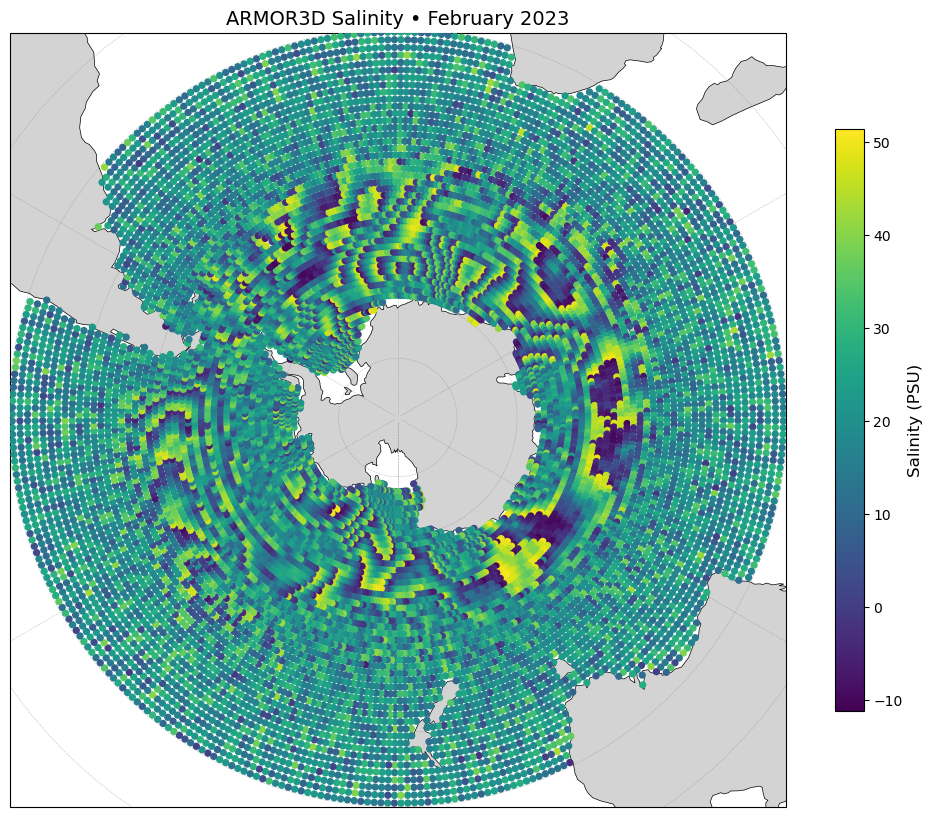

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ----------------------------------------------------------
# Load dataset
# ----------------------------------------------------------
input_csv = ("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX_v2/processing_steps/ARMOR3D_MLD_TS_SouthernOcean_1997_2024_monthly_1deg.csv")

# ----------------------------------------------------------
# Subset February 2023
# ----------------------------------------------------------
df_feb2023 = df[(df["year"] == 2023) & (df["month"] == 2)]

lat = df_feb2023["lat_center"].values
lon = df_feb2023["lon_center"].values
sal = df_feb2023["salinity"].values

# ----------------------------------------------------------
# Figure + South Polar Stereographic projection
# ----------------------------------------------------------
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=proj)

# Southern Ocean extent (to 30°S)
ax.set_extent([-180, 180, -90, -30], crs=ccrs.PlateCarree())

# ----------------------------------------------------------
# Map features (matching your figure style)
# ----------------------------------------------------------
ax.add_feature(cfeature.LAND, facecolor="lightgrey", zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color="black", zorder=2)

# Subtle gridlines similar to your figure
gl = ax.gridlines(
    draw_labels=False,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--"
)

# ----------------------------------------------------------
# Scatter salinity points
# ----------------------------------------------------------
sc = ax.scatter(
    lon, lat,
    c=sal,
    cmap="viridis",
    s=18,
    transform=ccrs.PlateCarree(),
    zorder=3
)

# Colorbar
cb = plt.colorbar(sc, orientation="vertical", shrink=0.6, pad=0.05)
cb.set_label("Salinity (PSU)", fontsize=12)

# Title
plt.title("ARMOR3D Salinity • February 2023", fontsize=14)

plt.tight_layout()
plt.show()


In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ----------------------------------------------------------
# Open dataset
# ----------------------------------------------------------
ncfile = (
    "/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/data/ARMOR-3D/"
    "cmems_obs-mob_glo_phy_my_0.125deg_P1M-m_so-to-mlotst_179.94W-179.94E_82.19S-89.94N_0.00m_1993-01-01-2024-12-01.nc"
)

ds = xr.open_dataset(ncfile)

# Inspect variable names
print(ds)

# ----------------------------------------------------------
# Select February 2023
# ----------------------------------------------------------
ds_feb2023 = ds.sel(time="2023-02")

# Assuming salinity variable is named "so"
sal = ds_feb2023["so"].squeeze()

lats = ds["latitude"]
lons = ds["longitude"]

# ----------------------------------------------------------
# Polar plot
# ----------------------------------------------------------
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=proj)

# Southern Ocean extents
ax.set_extent([-180, 180, -90, -30], crs=ccrs.PlateCarree())

# Add land, coastlines (match your style)
ax.add_feature(cfeature.LAND, color="lightgrey", zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color="black", zorder=2)

# Clean gridlines
ax.gridlines(
    draw_labels=False,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--"
)

# ----------------------------------------------------------
# Plot salinity field
# ----------------------------------------------------------
pcm = ax.pcolormesh(
    lons,
    lats,
    sal,
    cmap="viridis",
    transform=ccrs.PlateCarree(),
    shading="nearest",
    zorder=3
)

# Colorbar
cb = plt.colorbar(pcm, orientation="vertical", shrink=0.6, pad=0.05)
cb.set_label("Salinity (PSU)", fontsize=12)

plt.title("ARMOR3D Salinity • February 2023", fontsize=14)
plt.tight_layout()
plt.show()


<xarray.Dataset> Size: 18GB
Dimensions:    (depth: 1, latitude: 1378, longitude: 2880, time: 384)
Coordinates:
  * depth      (depth) int16 2B 0
  * latitude   (latitude) float32 6kB -82.19 -82.06 -81.94 ... 89.69 89.81 89.94
  * longitude  (longitude) float32 12kB -179.9 -179.8 -179.7 ... 179.8 179.9
  * time       (time) datetime64[ns] 3kB 1993-01-01 1993-02-01 ... 2024-12-01
Data variables:
    so         (time, depth, latitude, longitude) float32 6GB ...
    to         (time, depth, latitude, longitude) float32 6GB ...
    mlotst     (time, latitude, longitude) float32 6GB ...
Attributes:
    history:                   2025-10-13 20:10:31 ARMOR3D REP - TSHUV Global...
    title:                     ARMOR3D REP - TSHUVMld Global Ocean Observatio...
    Conventions:               CF-1.0
    institution:               CLS
    copernicusmarine_version:  2.2.5


/home/ldelaigue/miniconda3/envs/soca/lib/python3.11/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


In [6]:
import pandas as pd
f = "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/PREDICTION_MATRIX_v2/processing_steps/ARMOR3D_MLD_TS_SouthernOcean_1997_2024_monthly_1deg.csv"
df = pd.read_csv(f)
print("rows:", len(df))
print("lat_center min/max:", df["lat_center"].min(), df["lat_center"].max())
print("unique top 10 lats:", sorted(df["lat_center"].unique())[-10:])


rows: 5637120
lat_center min/max: -78.5 -30.5
unique top 10 lats: [np.float64(-39.5), np.float64(-38.5), np.float64(-37.5), np.float64(-36.5), np.float64(-35.5), np.float64(-34.5), np.float64(-33.5), np.float64(-32.5), np.float64(-31.5), np.float64(-30.5)]
